In [1]:
# import
import pandas as pd
import requests
from IPython.display import display
from datetime import datetime
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
# ETL(Extract, Transform, Load) Block:
def get_flight_data():
    # API - מאגר טיסות - EXTRACT
   
    # מזהה משאב(מגיע מהאתר)
    resource_id = "e83f763b-b7d7-479e-b172-ae981ddc6de5"

    url = f"https://data.gov.il/api/3/action/datastore_search?resource_id={resource_id}"

    # send requests to website and get response(code)
    response = requests.get(url)
    
    if response.status_code != 200:
        print(f"There is a problem: {response.status_code}")
        return None
    
    # parsing  the data we got
    data = response.json()
    
    # convert to DataFrame
    records = data['result']['records']
    df_flights = pd.DataFrame(records)
    
    #TRANSFORM

    # Rename columns to meaningful names
    df_flights = df_flights.rename(columns={
        '_id': 'id',
        'CHOPER': 'airline_code',
        'CHOPERD': 'airline_name',
        'CHFLTN': 'flight_number',
        'CHAORD': 'direction',
        'CHSTOL': 'scheduled_time',
        'CHPTOL': 'actual_time',
        'CHLOC1': 'airport_code',
        'CHLOC1D': 'airport_name',
        'CHLOC1TH': 'city_hebrew',
        'CHLOC1T': 'city_english',
        'CHLOC1CH': 'country_hebrew',
        'CHLOCCT': 'country_english',
        'CHTERM': 'terminal',
        'CHCINT': 'checkin_counters',
        'CHCKZN': 'checkin_zone',
        'CHRMINE': 'flight_status',
        'CHRMINH': 'flight_status_hebrew'
    }, errors='ignore')

    df_flights['terminal'] = pd.to_numeric(df_flights['terminal'], errors='coerce').astype('Int8')
    df_flights['flight_number'] = df_flights['flight_number'].astype(str)
    df_flights['scheduled_time'] = pd.to_datetime(df_flights['scheduled_time'])
    df_flights['actual_time'] = pd.to_datetime(df_flights['actual_time'])
    df_flights['terminal'] = pd.to_numeric(df_flights['terminal'], errors='coerce').astype('Int8')

    # missing values:
    # flights that are landing they are arrivel = mean no need to checkin so fill the empty to 'N/A'
    df_flights.loc[df_flights['direction'] == 'A', ['checkin_counters', 'checkin_zone']] = 'N/A'

    # flights that are leaving they are departure = means they do need to do check in so, if there is empty for any reason fill it as 'Missing'
    mask_missing_departures = (df_flights['direction'] == 'D') & (df_flights['checkin_counters'].isna())
    df_flights.loc[mask_missing_departures, ['checkin_counters', 'checkin_zone']] = 'Missing'
    #return to us the df - LOAD
    return df_flights


In [3]:
# update data
df_flights = get_flight_data()

# quick check for missing and duplicates rows:
# print(f"For df_flights there is: {df_flights.duplicated().sum()} duplicates rows")
# print(f"For df_flights there is: {df_flights.isna().sum()} missing values")


### EDA - Exploratory Data Analysis

In [14]:
# display the table
display(df_flights.head())

# look at the data in static way
df_flights.describe()

,id,airline_code,flight_number,airline_name,scheduled_time,actual_time,direction,airport_code,airport_name,city_hebrew,city_english,country_hebrew,country_english,terminal,checkin_counters,checkin_zone,flight_status,flight_status_hebrew,delay
0,1,EY,607,ETIHAD AIRWAYS,2026-06-23 11:20:00,2026-06-23 11:32:00,A,AUH,ABU DHABI,אבו דאבי,ABU DHABI,איחוד האמירויות הערב,UNITED ARAB EMIRATES,3,N/A,N/A,LANDED,נחתה,12.0
1,2,LY,9614,EL AL ISRAEL AIRLINES,2026-06-23 11:20:00,2026-06-23 11:32:00,A,AUH,ABU DHABI,אבו דאבי,ABU DHABI,איחוד האמירויות הערב,UNITED ARAB EMIRATES,3,N/A,N/A,LANDED,נחתה,12.0
2,3,6H,883,ISRAIR AIRLINES,2026-06-23 11:00:00,2026-06-23 11:36:00,D,BUS,BATUMI,בטומי,BATUMI,גיאורגיה,GEORGIA,3,201-214,G,DEPARTED,המריאה,36.0
3,4,IZ,368,ARKIA ISRAELI AIRLINES,2026-06-23 11:50:00,2026-06-23 11:37:00,A,TIV,TIVAT,טיבאת,TIVAT,מונטנגרו,MONTENEGRO,3,N/A,N/A,LANDED,נחתה,-13.0
4,5,6H,048,ISRAIR AIRLINES,2026-06-23 11:30:00,2026-06-23 11:40:00,A,ETM,RAMON,אילת - רמון,RAMON,ישראל,ISRAEL,3,N/A,N/A,LANDED,נחתה,10.0


,id,scheduled_time,actual_time,terminal,delay
count,2303.000000,2303,2303,2303.0,2303.000000
mean,1152.000000,2026-06-25 05:29:03.855840256,2026-06-25 05:38:16.621797632,3.0,9.212766
min,1.000000,2026-06-22 20:15:00,2026-06-23 11:32:00,3.0,-85.000000
25%,576.500000,2026-06-24 08:50:00,2026-06-24 09:15:00,3.0,0.000000
50%,1152.000000,2026-06-25 06:00:00,2026-06-25 06:00:00,3.0,0.000000
75%,1727.500000,2026-06-26 01:05:00,2026-06-26 01:05:00,3.0,0.000000
max,2303.000000,2026-06-27 11:30:00,2026-06-27 11:30:00,3.0,970.000000
std,664.963157,NaN,NaN,0.0,37.306336


In [16]:
# create delay column:
df_flights['delay'] = (df_flights['actual_time'] - df_flights['scheduled_time']).dt.total_seconds()/60

display(df_flights.head(15))

,id,airline_code,flight_number,airline_name,scheduled_time,actual_time,direction,airport_code,airport_name,city_hebrew,city_english,country_hebrew,country_english,terminal,checkin_counters,checkin_zone,flight_status,flight_status_hebrew,delay
0,1,EY,607,ETIHAD AIRWAYS,2026-06-23 11:20:00,2026-06-23 11:32:00,A,AUH,ABU DHABI,אבו דאבי,ABU DHABI,איחוד האמירויות הערב,UNITED ARAB EMIRATES,3,N/A,N/A,LANDED,נחתה,12.0
1,2,LY,9614,EL AL ISRAEL AIRLINES,2026-06-23 11:20:00,2026-06-23 11:32:00,A,AUH,ABU DHABI,אבו דאבי,ABU DHABI,איחוד האמירויות הערב,UNITED ARAB EMIRATES,3,N/A,N/A,LANDED,נחתה,12.0
2,3,6H,883,ISRAIR AIRLINES,2026-06-23 11:00:00,2026-06-23 11:36:00,D,BUS,BATUMI,בטומי,BATUMI,גיאורגיה,GEORGIA,3,201-214,G,DEPARTED,המריאה,36.0
3,4,IZ,368,ARKIA ISRAELI AIRLINES,2026-06-23 11:50:00,2026-06-23 11:37:00,A,TIV,TIVAT,טיבאת,TIVAT,מונטנגרו,MONTENEGRO,3,N/A,N/A,LANDED,נחתה,-13.0
4,5,6H,048,ISRAIR AIRLINES,2026-06-23 11:30:00,2026-06-23 11:40:00,A,ETM,RAMON,אילת - רמון,RAMON,ישראל,ISRAEL,3,N/A,N/A,LANDED,נחתה,10.0
5,6,W6,7062,WIZZAIR,2026-06-23 11:25:00,2026-06-23 11:42:00,D,BTS,BRATISLAVA,ברטיסלבה,BRATISLAVA,סלובקיה,SLOVAKIA,3,59-65,C,DEPARTED,המריאה,17.0
6,7,IZ,741,ARKIA ISRAELI AIRLINES,2026-06-23 10:30:00,2026-06-23 11:43:00,D,CDG,PARIS-CHARLES DE GAULLE,פריס,PARIS,צרפת,FRANCE,3,14-33,A,DEPARTED,המריאה,73.0
7,8,U8,108,TUS AIRWAYS,2026-06-23 11:45:00,2026-06-23 11:50:00,A,LCA,LARNACA,לרנקה,LARNACA,קפריסין,CYPRUS,3,N/A,N/A,LANDED,נחתה,5.0
8,9,W4,6924,WIZZ AIR MALTA,2026-06-23 11:00:00,2026-06-23 11:52:00,D,NAP,NAPLES-CAPODICHINO,נאפולי,NAPLES,איטליה,ITALY,3,59-65,C,DEPARTED,המריאה,52.0
9,10,LY,5108,EL AL ISRAEL AIRLINES,2026-06-23 11:50:00,2026-06-23 11:53:00,A,TBS,TBILISI,טביליסי,TBILISI,גיאורגיה,GEORGIA,3,N/A,N/A,LANDED,נחתה,3.0


### The Goal of Project:
#### 1.How many flight from start of the day till now?
#### 2. 

In [11]:
# 1.How many flight from start of the day till now?
# to get the date of today
now = datetime.now()
today = now.date()

today_flight = df_flights[
    (df_flights['actual_time'].dt.date == today) &
    (df_flights['actual_time'] <= now)
]

departures = today_flight[today_flight['direction'] == 'D']
arrivals = today_flight[today_flight['direction'] == 'A']

print(f"Today is {today} was {len(today_flight)} flights")
print(f"Today is {today} was {len(departures)} departures")
print(f"Today is {today} was {len(arrivals)} arrivals")

Today is 2026-06-24 was 299 flights
Today is 2026-06-24 was 163 departures
Today is 2026-06-24 was 136 arrivals


In [7]:
# 2. Which flight company is popular
flight_company = today_flight['airline_name'].value_counts()
# print(flight_company.head(5))

# bar chart to display the popular flight company today:
# first convert flight_company into df for easy create plot:
plot_flight_company = flight_company.reset_index()


# top 5 airline - head(5)
top_airline = plot_flight_company.sort_values(by='count', ascending=False).head(5)

# columns names
top_airline.columns = ['airline_name', 'count']

#color palette:
my_custom_palette = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F'] 

# bulid the chart:
fig = px.bar(
    top_airline, x='count', y='airline_name',orientation='h',color='airline_name',color_discrete_sequence=my_custom_palette,
    title="Number of flights by airline:", labels={'count':'Number of flights','airline_name':'Flight Company'})

fig.show()


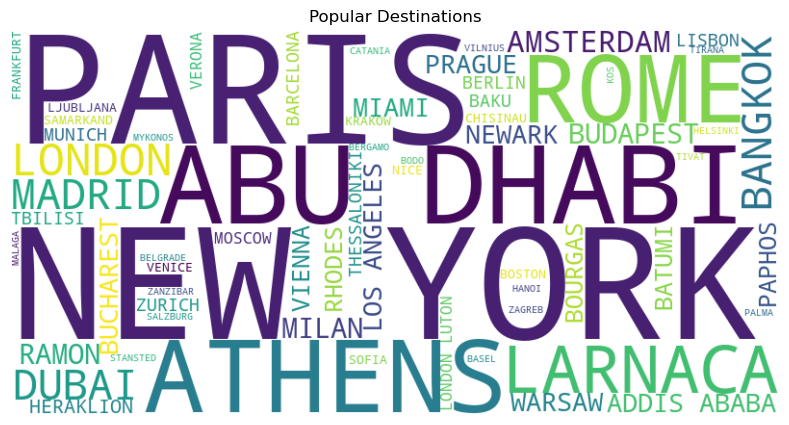

In [13]:
# 3. Which destinations are popular - Most Popular Destinations:
# drop empty cells, remove spaces and upper the words
df_clean = today_flight['city_english'].dropna().str.strip().str.upper()

# how many time city show up
city_counts = df_clean.value_counts()

# print the popular destinations
# print(today_flight['city_english'].unique())

# wordCloud chart:
wordcloud = WordCloud(
    width=800, height=400, 
    background_color='white', 
    colormap='viridis',
    random_state=42
).generate_from_frequencies(city_counts.to_dict())

# display wordCloud chart:
plt.figure(figsize=(15,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Destinations")
plt.show()

In [9]:
# 4. How many of the airlines are Israeli?"
 
today_flight = today_flight.copy()

israeli_airline = ['EL AL ISRAEL AIRLINES', 'ARKIA ISRAELI AIRLINES', 'ISRAIR AIRLINES']

# new column to sort by israeli or foreign
today_flight.loc[:, 'israeli_vs_foreign'] = today_flight['airline_name'].apply(lambda x: 'Israeli' if x in israeli_airline else 'Foreign')

flight_distribution = today_flight['israeli_vs_foreign'].value_counts()

# chart:
fig = px.pie(
    values=flight_distribution.values,
    names=flight_distribution.index,
    title="Israeli vs Foreign Airlines:",
    hole=0.4,
    color=flight_distribution.index,
    color_discrete_map={'Israeli': "#A8C6F9", 'Foreign': '#EF553B'}
)

# size of chart
fig.update_layout(
    width=600,  
    height=500
)

fig.show()

In [10]:
# check the dates of flight scheduled_time:
print(df_flights['scheduled_time'].min())
print(df_flights['scheduled_time'].max())

2026-06-22 20:15:00
2026-06-27 11:30:00
